<p style="font-family: Cambria; text-align: center; font-size: 48px;">
    2.Descriptive Analysis
</p>

In [3]:
#Importing all the Necessary Libraries
import warnings
warnings.simplefilter("ignore", UserWarning)
import pandas as pd
import numpy as np
from decimal import Decimal
import os
import glob
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#Reading the cleaned data 
df=pd.read_excel(r"C:\Data Analytics\12_PythonPioneers_Cleaned_data.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7527 entries, 0 to 7526
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Patient ID                    7527 non-null   object        
 1   Date                          7527 non-null   datetime64[ns]
 2   Hour                          7527 non-null   int64         
 3   Glucose                       7525 non-null   float64       
 4   Heart Rate                    7527 non-null   int64         
 5   Steps                         7527 non-null   int64         
 6   Calories                      7527 non-null   float64       
 7   Bolus Volume Delivered        7527 non-null   float64       
 8   Basal Rate                    7527 non-null   float64       
 9   Carb Input                    7527 non-null   float64       
 10  Bolus Category                7527 non-null   object        
 11  Age                           

In [4]:
#Creating a copy of the original data to work on, so that the original data is not modified
df=data.copy()

In [15]:
cols = ['Glucose', 'Basal Rate', 'Bolus Volume Delivered', 'Carb Input']

df[cols] = df[cols].astype('float32').round(2)

df['Calories'] = df['Calories'].round(0).astype('int64')

pd.options.display.float_format = '{:.2f}'.format

df.head(25)

,Patient ID,Date,Hour,Glucose,Heart Rate,Steps,Calories,Bolus Volume Delivered,Basal Rate,Carb Input,Bolus Category,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,2018-06-13,18,328.00,84,54,25,0.00,0.09,0.00,No insulin,34,Male,Other,6.30,4.50,80
1,HUPA0001P,2018-06-13,19,275.92,96,1376,139,0.00,0.08,0.00,No insulin,34,Male,Other,6.30,4.50,80
2,HUPA0001P,2018-06-13,20,141.75,100,1884,174,0.00,0.08,0.00,No insulin,34,Male,Other,6.30,4.50,80
3,HUPA0001P,2018-06-13,21,80.08,96,160,95,3.50,0.01,4.00,High dose,34,Male,Other,6.30,4.50,80
4,HUPA0001P,2018-06-13,22,153.42,91,213,72,0.00,0.03,0.00,No insulin,34,Male,Other,6.30,4.50,80
5,HUPA0001P,2018-06-13,23,144.17,89,228,71,0.00,0.01,0.00,No insulin,34,Male,Other,6.30,4.50,80
6,HUPA0001P,2018-06-14,0,156.50,84,0,49,0.00,0.05,0.00,No insulin,34,Male,Other,6.30,4.50,80
7,HUPA0001P,2018-06-14,1,178.25,83,0,49,0.00,0.07,0.00,No insulin,34,Male,Other,6.30,4.50,80
8,HUPA0001P,2018-06-14,2,175.33,74,28,53,0.00,0.07,0.00,No insulin,34,Male,Other,6.30,4.50,80
9,HUPA0001P,2018-06-14,3,129.58,70,0,48,0.00,0.05,0.00,No insulin,34,Male,Other,6.30,4.50,80


In [6]:
patient_df = df.groupby(['Patient ID']).agg({
    'Glucose': 'mean',
    'Heart Rate': 'mean',
    'Steps': 'sum',
    'Calories': 'sum',
    'Bolus Volume Delivered': 'mean',
    'Basal Rate': 'mean',
    'Carb Input': 'mean',
    'Age': 'first',
    'Average Sleep Duration (hrs)': 'first',
    'Sleep Quality (1-10)': 'first',
    '% with Sleep Disturbances': 'first'
    
}).reset_index()

In [7]:
cols = ['Glucose', 'Basal Rate', 'Bolus Volume Delivered', 'Carb Input']

patient_df[cols] = (
    patient_df[cols]
    .astype('float32')
    .round(2)
)

#Calorie as Whole number
patient_df['Calories'] = patient_df['Calories'].round(0).astype('int64')

# Use Decimal (exact precision)

from decimal import Decimal

patient_df[cols] = patient_df[cols].applymap(lambda x: Decimal(str(x)).quantize(Decimal('0.00')))

pd.options.display.float_format = '{:.2f}'.format
patient_df.head(25)

C:\Users\bgaya\AppData\Local\Temp\ipykernel_45644\3568252931.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  patient_df[cols] = patient_df[cols].applymap(lambda x: Decimal(str(x)).quantize(Decimal('0.00')))


,Patient ID,Glucose,Heart Rate,Steps,Calories,Bolus Volume Delivered,Basal Rate,Carb Input,Age,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,181.73,80.34,79739,24250,0.46,0.05,0.35,34,6.30,4.50,80
1,HUPA0002P,113.38,66.20,124830,32406,0.87,0.09,2.39,49,6.60,4.40,40
2,HUPA0003P,143.27,77.58,103340,35128,0.85,0.05,1.38,64,5.30,5.20,70
3,HUPA0004P,180.35,77.68,97763,34101,1.79,0.07,7.59,34,5.20,6.90,60
4,HUPA0005P,147.71,84.03,52003,21428,0.31,0.07,0.27,49,5.80,7.90,30
5,HUPA0006P,163.51,65.11,77879,22544,1.18,0.08,1.17,35,6.60,4.20,60
6,HUPA0007P,173.02,69.71,177522,53683,1.46,0.08,0.86,67,7.10,6.00,80
7,HUPA0009P,194.06,84.19,180507,31298,0.40,0.09,0.16,65,6.60,4.60,40
8,HUPA0010P,136.16,77.78,132793,21495,0.38,0.06,0.42,22,7.10,5.50,50
9,HUPA0011P,158.90,73.37,209547,31447,0.00,0.00,3.50,63,5.60,4.70,60


# Q1 How does consistency in daily physical activity (measured through step variability) relate to glucose variability across patients?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:Physical activity is a key factor influencing metabolic health and glucose regulation.Do patients with more consistent daily step patterns exhibit lower glucose variability compared to those with irregular activity levels.

In [ ]:
# Step variability
step_var = df.groupby('Patient ID')['Steps'].std()

# Glucose variability
glucose_var = df.groupby('Patient ID')['Glucose'].std()

# Combine into one dataframe
combined = pd.DataFrame({
    'Step_Var': step_var,
    'Glucose_Var': glucose_var
})

combined

In [17]:
# Create categories based on step variability
combined['Activity_Type'] = pd.qcut(combined['Step_Var'], 3, 
                                   labels=['Consistent','Moderate','Irregular'])

combined

,Step_Var,Glucose_Var,Activity_Type
Patient ID,,,
HUPA0001P,391.55,67.26,Consistent
HUPA0002P,583.48,58.05,Moderate
HUPA0003P,428.07,59.83,Consistent
HUPA0004P,455.86,81.44,Consistent
HUPA0005P,360.81,48.60,Consistent
HUPA0006P,606.64,81.47,Moderate
HUPA0007P,773.09,76.04,Irregular
HUPA0009P,797.21,46.05,Irregular
HUPA0010P,578.33,56.38,Moderate


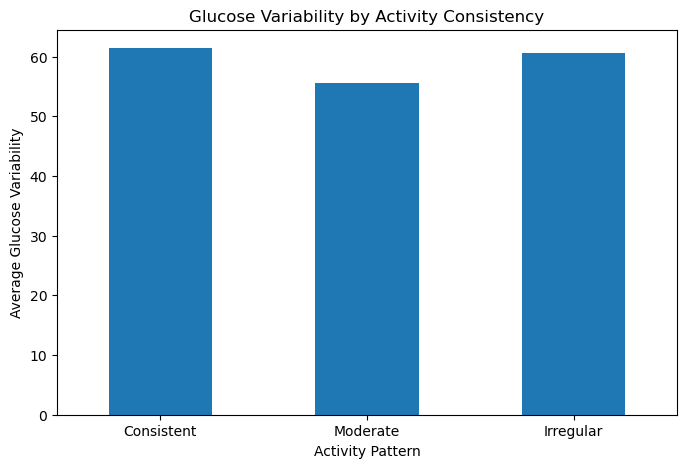

In [11]:
# Average glucose variability by activity type
result = combined.groupby('Activity_Type', observed=True)['Glucose_Var'].mean()

# Plot
result.plot(kind='bar', figsize=(8,5))

plt.title("Glucose Variability by Activity Consistency")
plt.xlabel("Activity Pattern")
plt.ylabel("Average Glucose Variability")
plt.xticks(rotation=0)
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Patients with moderate activity consistency exhibit the lowest glucose variability, suggesting that a balanced and flexible activity pattern leads to more stable glucose control compared to strictly consistent or highly irregular activity levels

# Q2 How does the ratio of insulin administered (bolus + basal) to carbohydrate intake vary across patients, and does this ratio correlate with effective glucose control?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:To maintain a stable glucose levels insulin level should be match with the carb intake, either too much and too littile insulin may create an imbalance in insulin, related to carb intake, This is to check weather patients maintain an effective insulin to carbohydarate balance and how it affects glucose.

In [19]:

# Total insulin
df['total_insulin'] = df['Bolus Volume Delivered'] + df['Basal Rate']

# Insulin-carb ratio
df['insulin_carb_ratio'] = df['total_insulin'] / df['Carb Input']

# Correlation
df[['insulin_carb_ratio', 'Glucose']].corr()

,insulin_carb_ratio,Glucose
insulin_carb_ratio,1.00,0.30
Glucose,0.30,1.00


In [20]:
# Check values first
print(df['Bolus Category'].unique())

# Map to numeric
mapping = {
    'No insulin': 0,
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df['Bolus_Num'] = df['Bolus Category'].map(mapping)

['No insulin' 'High dose' 'Low dose' 'Medium dose']


In [21]:
df['Total_Insulin'] = df['Bolus_Num'] + df['Basal Rate']

In [22]:
df_ratio = df[df['Carb Input'] > 0].copy()

In [23]:
df_ratio['Insulin_Carb_Ratio'] = df_ratio['Total_Insulin'] / df_ratio['Carb Input']

In [24]:
# Select needed columns and clean
clean_df = df_ratio[['Insulin_Carb_Ratio', 'Glucose']].dropna()

# Remove extreme / invalid values (important)
clean_df = clean_df[(clean_df['Insulin_Carb_Ratio'] > 0) & 
                    (clean_df['Insulin_Carb_Ratio'] < 1)]

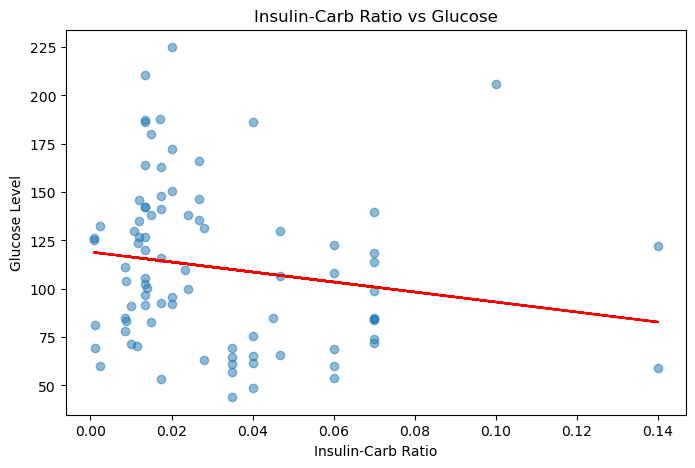

In [25]:
plt.figure(figsize=(8,5))

# Scatter
plt.scatter(clean_df['Insulin_Carb_Ratio'], clean_df['Glucose'], alpha=0.5)

# Trend line
z = np.polyfit(clean_df['Insulin_Carb_Ratio'], clean_df['Glucose'], 1)
p = np.poly1d(z)
plt.plot(clean_df['Insulin_Carb_Ratio'], p(clean_df['Insulin_Carb_Ratio']), color='red')

plt.xlabel("Insulin-Carb Ratio")
plt.ylabel("Glucose Level")
plt.title("Insulin-Carb Ratio vs Glucose")

plt.show()

In [26]:
correlation = clean_df[['Insulin_Carb_Ratio', 'Glucose']].corr()

print("Correlation Value:")
print(correlation)

Correlation Value:
                    Insulin_Carb_Ratio  Glucose
Insulin_Carb_Ratio                1.00    -0.17
Glucose                          -0.17     1.00


<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>The insulin-to-carbohydrate ratio varies across patients, indicating differences in insulin dosing relative to dietary intake. However, the correlation between this ratio and glucose levels is weak (r = -0.17), suggesting that while higher insulin coverage may slightly reduce glucose levels, it is not a strong standalone predictor of glycemic control

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Glucose levels generally decrease in the hours following periods of high physical activity, indicating that physical activity has a positive short-term impact on glucose control. However, the extent of reduction varies across patients, highlighting differences in individual physiological response and activity effectiveness.

# Q3. Does poor sleep quality contribute to unstable glucose levels?


<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: Sleep quality plays an important role in glucose regulation because poor sleep can affect insulin sensitivity, hormone balance, stress response, and overall metabolic recovery.
This analysis compares average glucose levels across different sleep quality scores to understand whether sleep behavior may influence diabetic control.
Instead of focusing only on insulin or diet, this helps evaluate whether lifestyle factors such as sleep are associated with higher glucose levels and potentially poorer diabetes management.
Understanding this relationship can help clinicians recommend sleep improvement strategies as part of personalized diabetes care.

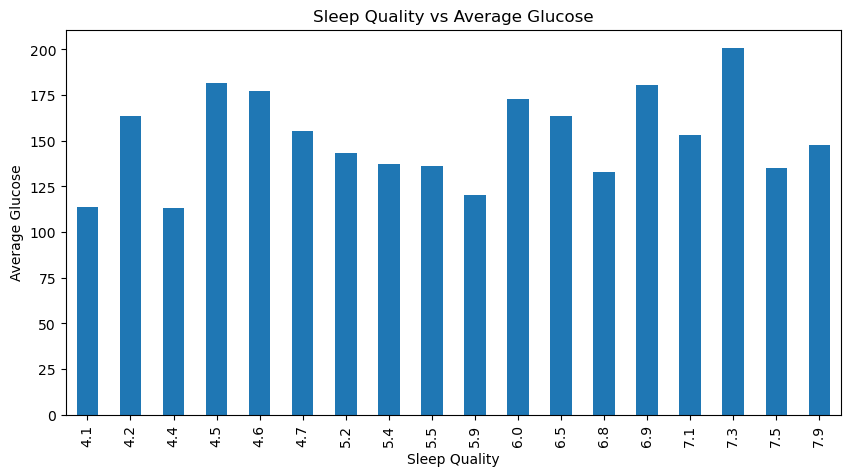

In [29]:
sleep_glucose = df.groupby("Sleep Quality (1-10)")["Glucose"].mean()

sleep_glucose.plot(kind="bar", figsize=(10,5))

plt.title("Sleep Quality vs Average Glucose")
plt.xlabel("Sleep Quality")
plt.ylabel("Average Glucose")
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> The visualization shows noticeable variation in average glucose levels across different sleep quality scores.
Some sleep quality groups, especially around 4.5, 4.6, 6.9, and 7.3, display relatively higher average glucose levels compared to other groups. Lower sleep quality scores also tend to show unstable glucose patterns.
However, the relationship is not perfectly linear, which suggests that sleep quality alone may not fully explain glucose behavior. Other factors such as carbohydrate intake, insulin dosage, activity level, and individual patient differences may also influence glucose outcomes.
Overall, the analysis suggests that sleep quality may contribute to glucose instability and should be considered as an important behavioral factor in diabetes management.

# Q4. Average Glucose across all patients,and how does it vary by age group
 
 

<p style="font-family: Cambria; font-size: 18px;"><b> <i>
Glucose levels are heavily influenced by lifestyle factors tied to age and gender. Glucose levels naturally trend upward as we age.For this analysis, we will be Calculating the Average Glucose for each patient 

In [34]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Calculating average glucose per patient
avg_glucose_daily = (
    df.groupby('Patient ID')['Glucose']
      .mean()
      .reset_index(name='Avg_Glucose')
)

# Extracting unique Age + Gender for each patient
patient_info = df[['Patient ID', 'Age', 'Gender']].drop_duplicates()

# Now Merging the demographics into the average glucose table
avg_glucose_daily = avg_glucose_daily.merge(
    patient_info,
    on='Patient ID',
    how='left'
)
avg_glucose_daily

,Patient ID,Avg_Glucose,Age,Gender
0,HUPA0001P,181.729240,34,Male
1,HUPA0002P,113.375902,49,Male
2,HUPA0003P,143.270444,64,Male
3,HUPA0004P,180.350602,34,Female
4,HUPA0005P,147.708137,49,Male
5,HUPA0006P,163.513403,35,Male
6,HUPA0007P,173.019534,67,Male
7,HUPA0009P,194.061411,65,Female
8,HUPA0010P,136.157430,22,Male
9,HUPA0011P,158.900218,63,Female


In [35]:
# Categorizing glucose value into clinical zones i.e. 
# Hypo(Hypoglycemia-Low Blood Sugar), In Range and Hyper(Hyperlycemia-High Blood Sugar)
def glucose_category(x):
    if x < 70:
        return 'Hypo'
    elif x <= 180:
        return 'In Range'
    else:
        return 'Hyper'

# Categorizing each patient daily Average glucose to the Different clinical categories (Hypo, In-Range, Hyper)
avg_glucose_daily['Glucose Category'] = avg_glucose_daily['Avg_Glucose'].apply(glucose_category)
avg_glucose_daily['Glucose Category']




0        Hyper
1     In Range
2     In Range
3        Hyper
4     In Range
5     In Range
6     In Range
7        Hyper
8     In Range
9     In Range
10       Hyper
11    In Range
12    In Range
13       Hyper
14    In Range
15    In Range
16       Hyper
17    In Range
18    In Range
19    In Range
20    In Range
21    In Range
22    In Range
23    In Range
24    In Range
Name: Glucose Category, dtype: object

In [38]:
# Creating age group with defined ranges and Categorizing each patient based on patients age's given in different age group
avg_glucose_daily['Age Group'] = pd.cut(
    avg_glucose_daily['Age'],
    bins=[0,18,35,50,65,100],
    labels=['Child', 'Young Adult', 'Adult', 'Middle Age', 'Senior']
)

# Finally counting the each age group. This classification is then used to Compare Average glucose across age groups
avg_glucose_daily['Age Group'].value_counts()

Age Group
Young Adult    10
Middle Age      8
Adult           5
Senior          2
Child           0
Name: count, dtype: int64

In [39]:
# Now, Finallly doing the Core Analysis of Average Glucose for each age groups
avg_glucose_by_age_group = (
    avg_glucose_daily.groupby('Age Group', observed=False)['Avg_Glucose']
    .mean()
    .reset_index(name='Avg_glucose_per_age_group')
)

avg_glucose_by_age_group = avg_glucose_by_age_group.sort_values(
    by='Avg_glucose_per_age_group',
    ascending=False
)
avg_glucose_by_age_group


,Age Group,Avg_glucose_per_age_group
3,Middle Age,160.917315
1,Young Adult,156.519878
4,Senior,153.000272
2,Adult,137.583069
0,Child,NaN


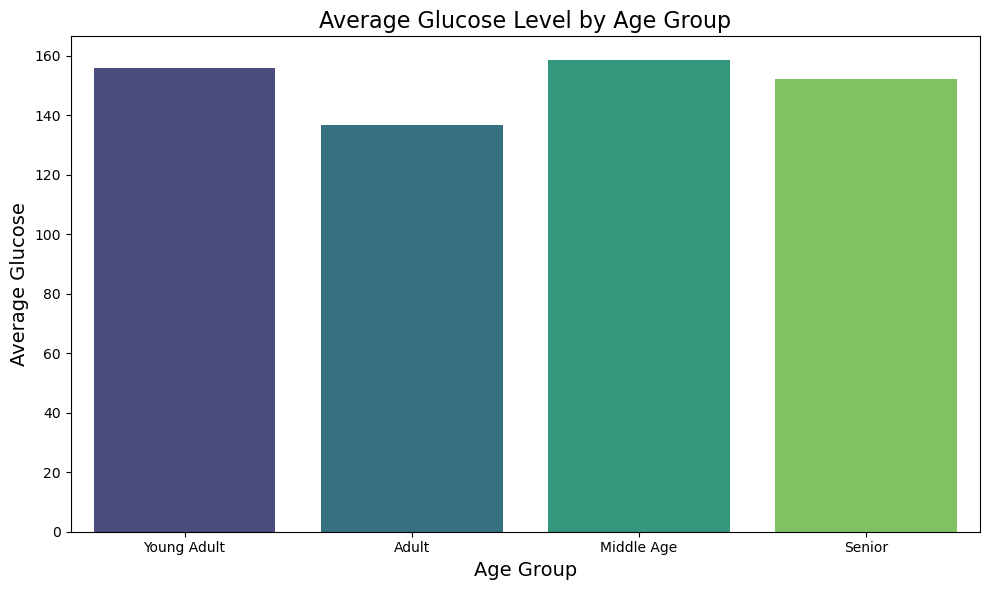

In [13]:
plot_df = avg_glucose_by_age_group.dropna(subset=['Avg_glucose_per_age_group']).copy()

plot_df['Age Group'] = plot_df['Age Group'].cat.remove_unused_categories()


plt.figure(figsize=(10,6))
sns.barplot(
    data=plot_df,
    x='Age Group',
    y='Avg_glucose_per_age_group',
     hue='Age Group',  # this is required & hence added in order to use the palette
    palette='viridis',
    legend=False 
)

plt.title('Average Glucose Level by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Average Glucose', fontsize=14)
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>  Above data analysis helps to understand that:
Middle-aged patients and young adults have poorer glucose control
Seniors are not the highest
Adults have the best control

# Q5. What is the racial and gender composition of the cohort, and are sleep disturbance rates systematically higher in any demographic subgroup?

In [26]:
#Racial composition of cohort

#If patients appear multiple times (many hourly rows per patient), first deduplicate patients.

patients = df.drop_duplicates(subset="Patient ID")

In [27]:
race_counts = patients["Race"].value_counts()

race_pct = (
    patients["Race"]
    .value_counts(normalize=True)
    * 100
)

print(race_counts)
print(race_pct)

Race
Black              7
Other              5
Native American    5
Hispanic           3
White              3
Asian              2
Name: count, dtype: int64
Race
Black              28.0
Other              20.0
Native American    20.0
Hispanic           12.0
White              12.0
Asian               8.0
Name: proportion, dtype: float64


In [28]:
gender_counts = patients["Gender"].value_counts()

gender_pct = (
    patients["Gender"]
    .value_counts(normalize=True)
    * 100
)

print(gender_counts)
print(gender_pct)

Gender
Male      16
Female     9
Name: count, dtype: int64
Gender
Male      64.0
Female    36.0
Name: proportion, dtype: float64


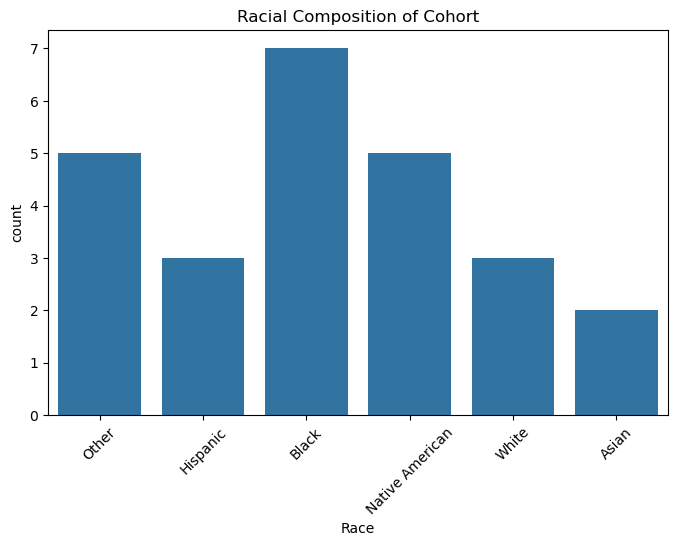

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(data=patients, x="Race")

plt.title("Racial Composition of Cohort")
plt.xticks(rotation=45)

plt.show()

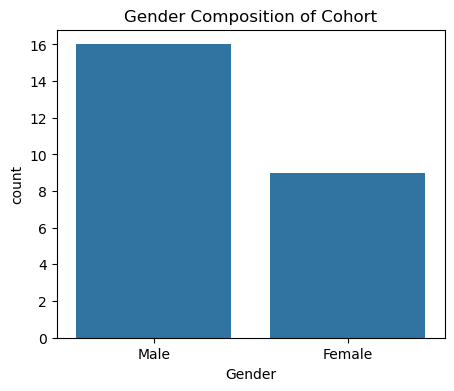

In [30]:
plt.figure(figsize=(5,4))

sns.countplot(data=patients, x="Gender")

plt.title("Gender Composition of Cohort")

plt.show()

In [31]:
#Sleep disturbance rates by gender
gender_sleep = (
    patients.groupby("Gender")
    ["% with Sleep Disturbances"]
    .mean()
    .sort_values(ascending=False)
)

print(gender_sleep)

Gender
Female    56.666667
Male      50.625000
Name: % with Sleep Disturbances, dtype: float64


In [32]:
#Sleep disturbance rates by race
race_sleep = (
    patients.groupby("Race")
    ["% with Sleep Disturbances"]
    .mean()
    .sort_values(ascending=False)
)

print(race_sleep)

Race
Asian              65.000000
Native American    58.000000
White              53.333333
Other              52.000000
Black              48.571429
Hispanic           46.666667
Name: % with Sleep Disturbances, dtype: float64


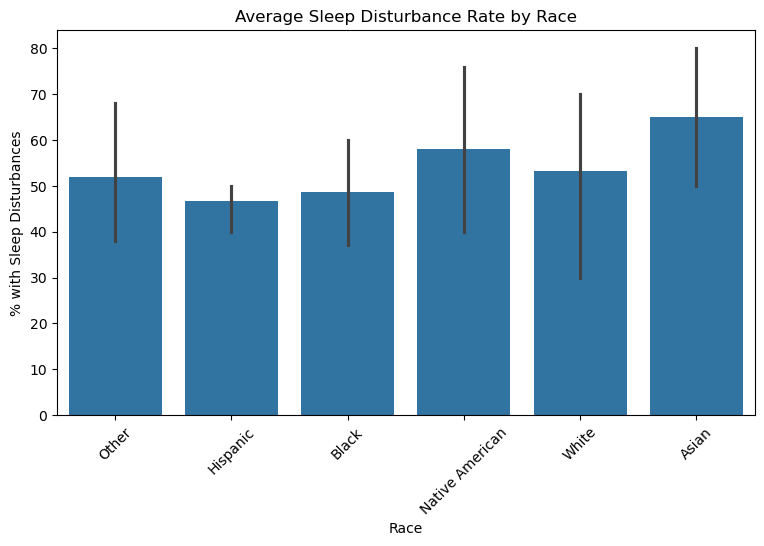

In [33]:
#Visualization of subgroup differences By race
plt.figure(figsize=(9,5))

sns.barplot(
    data=patients,
    x="Race",
    y="% with Sleep Disturbances",
    estimator="mean"
)

plt.title("Average Sleep Disturbance Rate by Race")
plt.xticks(rotation=45)

plt.show()

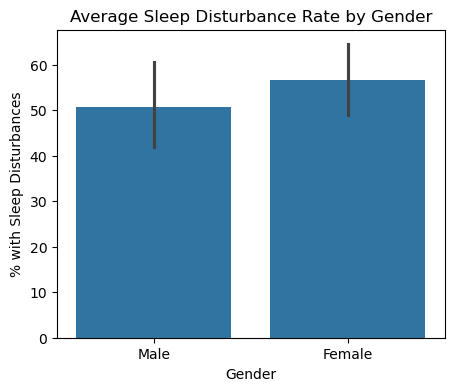

In [34]:
#By gender

plt.figure(figsize=(5,4))

sns.barplot(
    data=patients,
    x="Gender",
    y="% with Sleep Disturbances",
    estimator="mean"
)

plt.title("Average Sleep Disturbance Rate by Gender")

plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>
Cohort Demographic Composition
The cohort included participants from multiple racial and gender groups, enabling comparison of sleep disturbance burden across demographic subpopulations.

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>The analysis summarized::<br>
racial distribution of patients
gender distribution
average percentage of sleep disturbances within each subgroup
This helped identify whether sleep disruption patterns were disproportionately concentrated in specific demographic categories.</p>

# Q6.What is the breakdown of bolus categories (No insulin, Low, Medium, High dose) by gender and race are certain groups more likely to require high-dose boluses?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning:This reflects the reality that bolus insulin events are relatively rare in hourly wearable data, making the high-dose percentages though small in absolute terms clinically meaningful signals of which groups are managing the most intensive glucose control challenges.

In [6]:
gender_dist = pd.crosstab(df['Gender'], df['Bolus Category'], normalize='index') * 100
print(gender_dist)

Bolus Category  High dose  Low dose  Medium dose  No insulin
Gender                                                      
Female               5.68      1.62         2.29       90.40
Male                 9.28      4.15         4.30       82.27


In [7]:
race_dist = pd.crosstab(df['Race'], df['Bolus Category'], normalize='index') * 100
print(race_dist)

Bolus Category   High dose  Low dose  Medium dose  No insulin
Race                                                         
Asian                 4.88      6.50         5.89       82.72
Black                 7.99      5.76         2.65       83.60
Hispanic              7.88      1.08         1.84       89.20
Native American      10.89      1.97         4.84       82.29
Other                 5.44      2.20         4.83       87.52
White                 9.59      1.46         1.46       87.48


In [8]:
combined = pd.crosstab([df['Gender'], df['Race']], df['Bolus Category'], normalize='index') * 100
print(combined)

Bolus Category          High dose  Low dose  Medium dose  No insulin
Gender Race                                                         
Female Black                 9.99      3.14         1.86       85.02
       Hispanic              4.00      1.67         2.67       91.67
       Native American       6.60      0.51         0.17       92.72
       Other                 1.78      0.94         3.87       93.42
Male   Asian                 4.88      6.50         5.89       82.72
       Black                 6.66      7.51         3.17       82.66
       Hispanic              9.74      0.80         1.44       88.02
       Native American      13.48      2.86         7.66       76.00
       Other                10.62      3.98         6.19       79.20
       White                 9.59      1.46         1.46       87.48


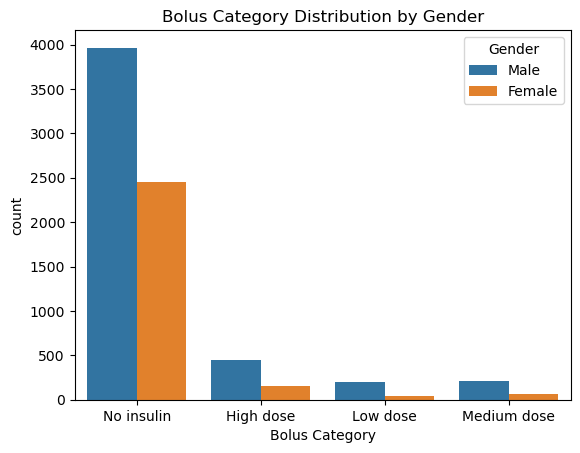

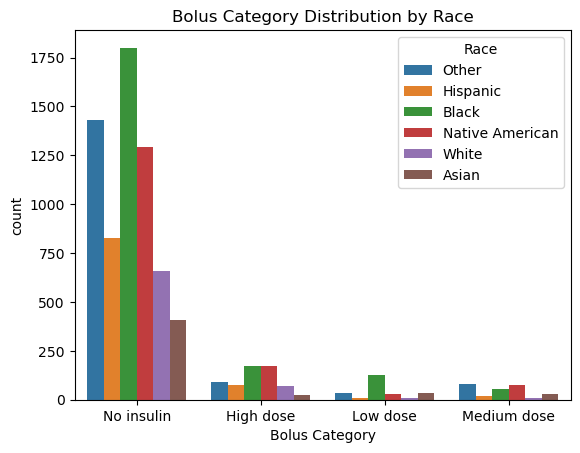

In [9]:

sns.countplot(data=df, x='Bolus Category', hue='Gender')
plt.title('Bolus Category Distribution by Gender')
plt.show()

sns.countplot(data=df, x='Bolus Category', hue='Race')
plt.title('Bolus Category Distribution by Race')
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>When comparing across genders within the same racial group, Native American males (13.48%) use high-dose bolus at nearly double the rate of Native American females (6.60%), the largest within-race gender gap in the cohort. The same directional gap appears in Hispanic patients — males at 9.74% vs females at 4.00%. The one exception is the Black subgroup, where females (9.99%) actually exceed males (6.66%) in high-dose usage, reversing the typical gender pattern observed elsewhere.

# Q7. Is this dataset a repeated cross-sectional sample or a longitudinal cohort, based on patient-level time coverage?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: The observation window duration was calculated per patient by counting the span of days between their first and last recorded date. A histogram was used rather than a table because it immediately shows the distribution shape — whether patients are clustered around a similar duration or spread unevenly — which directly affects how much trust to place in cross-patient comparisons

In [10]:
#Max and Min date for each patients

patient_range = df.groupby('Patient ID')['Date'].agg(['min','max'])

#Calculate total duration 
patient_range['duration_days'] = (patient_range['max'] - patient_range['min']).dt.days
patient_range

,min,max,duration_days
Patient ID,,,
HUPA0001P,2018-06-13,2018-06-27,14
HUPA0002P,2018-06-13,2018-06-24,11
HUPA0003P,2018-06-13,2018-06-26,13
HUPA0004P,2018-07-09,2018-07-20,11
HUPA0005P,2018-07-09,2018-07-22,13
HUPA0006P,2018-07-09,2018-07-17,8
HUPA0007P,2018-09-19,2018-10-02,13
HUPA0009P,2018-09-19,2018-10-02,13
HUPA0010P,2018-11-07,2018-11-17,10


In [12]:
df = df.sort_values(['Patient ID', 'Date'])
df['Year'] = df['Date'].dt.year
#gap between each visit
df['date_gap'] = df.groupby('Patient ID')['Date'].diff().dt.days
(df.groupby('Year')['Patient ID']
   .nunique())

Year
2018    11
2019     7
2020     6
2022     1
Name: Patient ID, dtype: int64

In [13]:
gap_summary = df.groupby('Patient ID')['date_gap'].agg(['mean', 'max', 'min'])
gap_summary

,mean,max,min
Patient ID,,,
HUPA0001P,0.04,1.00,0.00
HUPA0002P,0.04,1.00,0.00
HUPA0003P,0.04,1.00,0.00
HUPA0004P,0.04,1.00,0.00
HUPA0005P,0.04,1.00,0.00
HUPA0006P,0.04,1.00,0.00
HUPA0007P,0.04,1.00,0.00
HUPA0009P,0.04,1.00,0.00
HUPA0010P,0.04,1.00,0.00


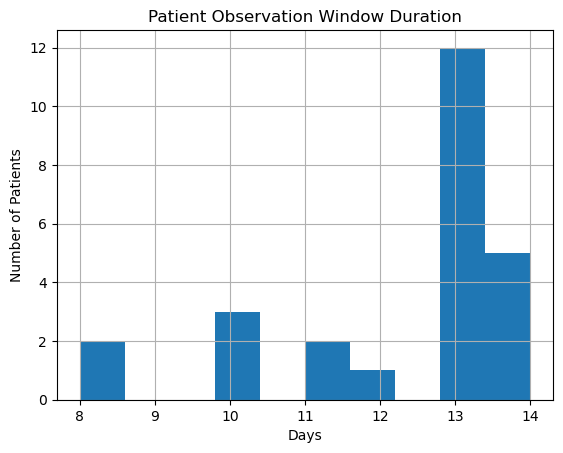

In [14]:
patient_range['duration_days'].hist()
plt.title('Patient Observation Window Duration')
plt.xlabel('Days')
plt.ylabel('Number of Patients')
plt.show()


<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Patients are observed in short, continuous monitoring windows rather than long-term follow-up
Most patients (17 out of 25) were observed for 13 to 14 days, giving the dataset a consistent and comparable monitoring duration across the majority of the cohort, which supports reliable analysis.
Seven patients have shorter windows of 8 to 12 months. Their averages are based on less data and should be treated with more caution when making comparisons.
The most important limitation is that no single patient appears across more than one year. Every patient's data sits entirely within one calendar year, so the 2018 to 2022 analysis is not tracking the same people improving or worsening over time. it is comparing different groups of patients across different years. This must be clearly stated when presenting any trend findings.

# Q8 .Which patients exhibit unstable glucose control patterns that may require intervention based on daily trend fluctuations?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: Patients exhibiting unstable glucose control patterns can be identified by measuring within-patient variability in daily glucose trends over the 14-day monitoring period. In this dataset, instability is quantified using the standard deviation of daily average glucose values per patient, where higher variability indicates inconsistent glucose regulation.
Patients with high variability are clinically important because fluctuating glucose patterns are often associated with:
Poor glycemic regulation
Irregular response to insulin, diet, or activity
Increased risk of hyperglycemic or hypoglycemic episodes
This approach allows us to move from single readings to pattern-based clinical risk detection, which is more reliable for identifying patients who may require intervention.

In [44]:
#To identify these patients, we first aggregate glucose at the daily level per patient, then measure variability across days using standard deviation. Higher standard deviation indicates greater instability in glucose control over the 14-day monitoring period.
patient_daily = df.groupby(['Patient ID', 'Date'])['Glucose'].mean().reset_index()
patient_variability = patient_daily.groupby('Patient ID')['Glucose'].agg(['mean', 'std']).reset_index()

def classify(std):
    if std > 38:
        return "Unstable"
    elif std > 20:
        return "Moderate"
    else:
        return "Stable"

patient_variability['Status'] = patient_variability['std'].apply(classify)
patient_variability = patient_variability.sort_values('std', ascending=False)
patient_variability

,Patient ID,mean,std,Status
12,HUPA0016P,148.03,39.43,Unstable
3,HUPA0004P,181.42,38.84,Unstable
22,HUPA0026P,152.10,32.90,Moderate
14,HUPA0018P,142.70,32.29,Moderate
5,HUPA0006P,160.88,31.88,Moderate
13,HUPA0017P,198.02,31.32,Moderate
20,HUPA0024P,166.10,31.23,Moderate
16,HUPA0020P,192.79,30.10,Moderate
10,HUPA0014P,183.39,29.85,Moderate
1,HUPA0002P,111.41,29.75,Moderate


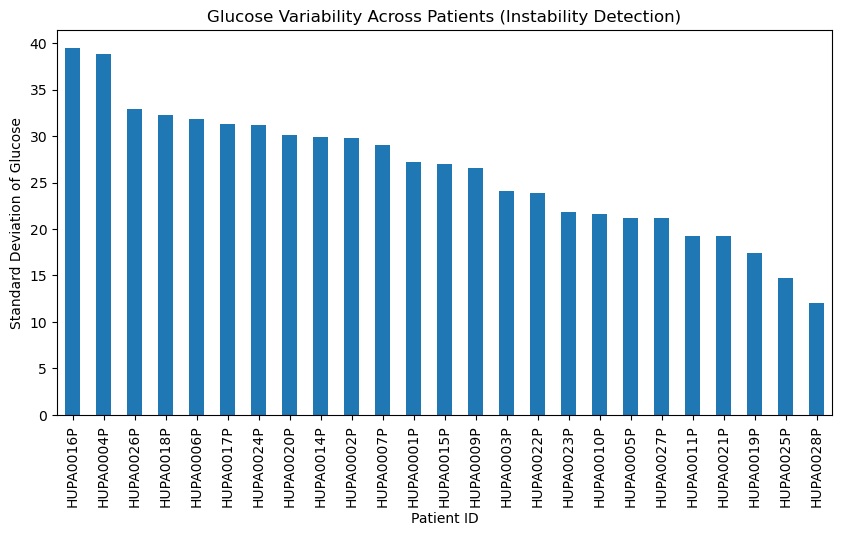

In [45]:

patient_variability.sort_values('std', ascending=False)\
    .set_index('Patient ID')['std']\
    .plot(kind='bar', figsize=(10,5))

plt.title("Glucose Variability Across Patients (Instability Detection)")
plt.ylabel("Standard Deviation of Glucose")
plt.show()


<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Patients were classified based on day-to-day glucose variability using standard deviation of daily glucose values. High variability patients are clinically significant because they exhibit unstable glycemic control patterns, which may indicate irregular physiological response to insulin, diet, or activity and increased risk of extreme glucose events

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Identified patients (ID 16,4) with the highest glucose variability (standard deviation) and visualized their to assess instability.
Patients were classified based on day-to-day glucose variability using standard deviation of daily glucose values. 
High variability patients are clinically significant because they exhibit unstable glycemic control patterns, which may indicate irregular physiological response to insulin, diet, or activity and increased risk of extreme glucose events.

# Q9 What percentage of patient-hours have zero bolus and zero carb input yet still show glucose above 180 suggesting endogenous hyperglycemia unrelated to meals?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: This question aims to identify episodes of endogenous hyperglycemia, where elevated glucose levels occur independently of food intake or meal-related insulin administration. Specifically, it focuses on patient-hours where both carbohydrate intake and bolus insulin delivery are zero, yet blood glucose remains above 180 mg/dL. In such cases, the hyperglycemia is unlikely to be driven by recent meals and instead may reflect underlying physiological factors such as insufficient basal insulin coverage, increased hepatic glucose production, insulin resistance, or stress-related hormonal responses. By isolating these conditions, the analysis helps distinguish between meal-related glucose spikes and non-meal-related metabolic dysfunction, which is important for guiding more targeted clinical interventions.

Overall: 29.32% of quiet hours have glucose > 180
            total  hyper_hours  pct_hyper
Patient ID                               
HUPA0017P     261          166       63.6
HUPA0009P     256          141       55.1
HUPA0014P     279          150       53.8
HUPA0020P     232          118       50.9
HUPA0007P     243          107       44.0
HUPA0024P     220           92       41.8
HUPA0004P     222           92       41.4
HUPA0001P     271          106       39.1
HUPA0015P     317          118       37.2
HUPA0019P     253           84       33.2
HUPA0016P     227           73       32.2
HUPA0006P     143           43       30.1
HUPA0026P     334          100       29.9
HUPA0018P     325           97       29.8
HUPA0011P     266           78       29.3
HUPA0005P     263           57       21.7
HUPA0003P     229           47       20.5
HUPA0021P     173           35       20.2
HUPA0023P     264           42       15.9
HUPA0002P     211           24       11.4
HUPA0027P     246         

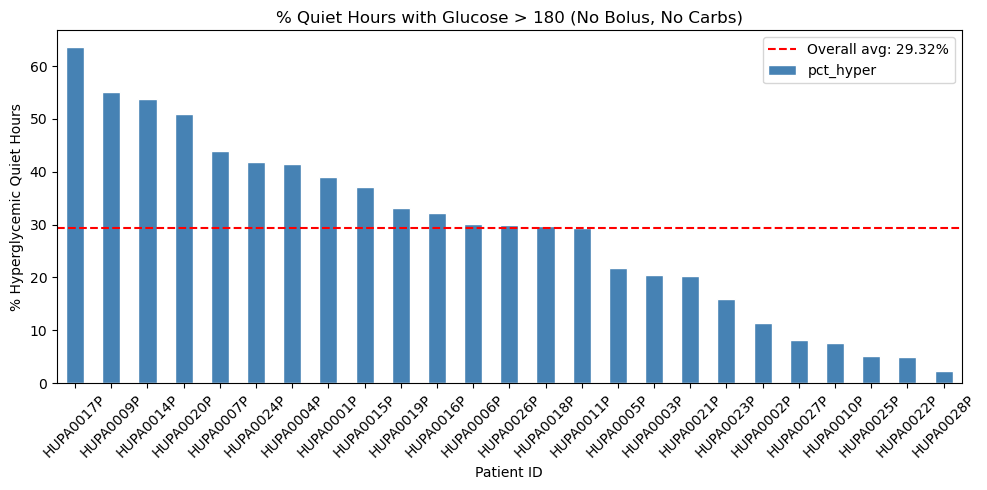

In [5]:

df = pd.read_excel("12_PythonPioneers_cleaned_data.xlsx")

# Step 1: Filter quiet hours (no bolus, no carbs)
quiet = df[
    (df["Bolus Volume Delivered"] == 0.0) &
    (df["Carb Input"] == 0.0)
].copy()

# Step 2: Flag hyperglycemia
quiet["hyper"] = quiet["Glucose"] > 180

# Step 3: Overall %
overall_pct = round(100 * quiet["hyper"].mean(), 2)
print(f"Overall: {overall_pct}% of quiet hours have glucose > 180")

# Step 4: Per-patient %
patient_stats = (
    quiet.groupby("Patient ID")["hyper"]
    .agg(total="count", hyper_hours="sum")
    .assign(pct_hyper=lambda x: round(100 * x["hyper_hours"] / x["total"], 1))
    .sort_values("pct_hyper", ascending=False)
)
print(patient_stats)

# Step 5: Bar chart
patient_stats["pct_hyper"].plot(
    kind="bar", figsize=(10, 5), color="steelblue", edgecolor="white"
)
plt.axhline(overall_pct, color="red", linestyle="--", label=f"Overall avg: {overall_pct}%")
plt.title("% Quiet Hours with Glucose > 180 (No Bolus, No Carbs)")
plt.xlabel("Patient ID")
plt.ylabel("% Hyperglycemic Quiet Hours")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>Nearly 1 in 3 quiet hours (29.Nearly 1 in 3 quiet hours (29.3%) show glucose above 180 mg/dL with zero carbs and zero bolus, confirming that a large share of hyperglycemia in this cohort is endogenous driven by the liver, not meals.
Six patients exceed 40%, with the top four crossing 50%, indicating a clear basal coverage gap. Seven patients sit below 20%, proving adequate basal suppression is achievable and serving as an internal benchmark. The only actionable lever here is basal insulin this finding directly sets up a prescriptive question on who needs a rate adjustment and by how much.

# Q10 .How does average sleep duration vary across patients, and does shorter sleep duration associate with higher glucose levels?

<p style="font-family: Cambria; font-size: 18px;"><b> <i>Reasoning: This question aims to explore the relationship between sleep duration and glucose regulation across patients. Sleep is a critical physiological factor that influences hormonal balance, insulin sensitivity, and glucose metabolism. By analyzing average sleep duration across patients and comparing it with their glucose levels, we can identify whether reduced sleep is associated with poorer glycemic control

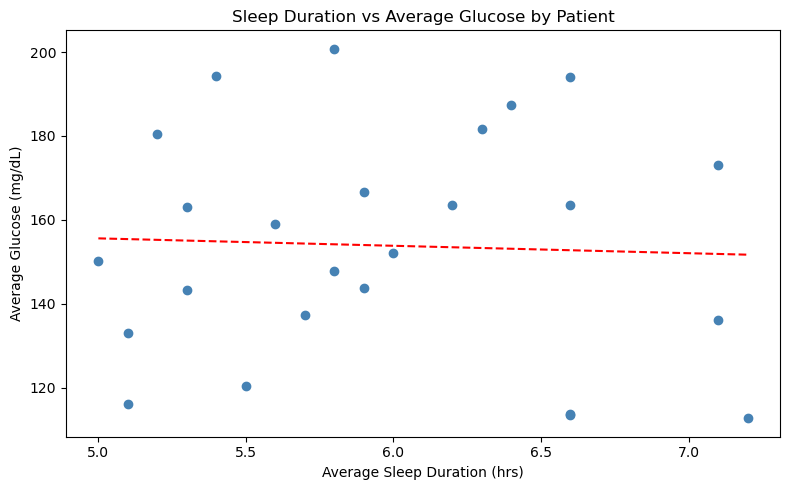

In [8]:
sleep_glucose = (
    df.groupby("Patient ID")
    .agg(
        Avg_Sleep=("Average Sleep Duration (hrs)", "first"),
        Avg_Glucose=("Glucose", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(8,5))
plt.scatter(sleep_glucose["Avg_Sleep"], sleep_glucose["Avg_Glucose"], color="steelblue")

z = np.polyfit(sleep_glucose["Avg_Sleep"], sleep_glucose["Avg_Glucose"], 1)
p = np.poly1d(z)
plt.plot(sorted(sleep_glucose["Avg_Sleep"]), p(sorted(sleep_glucose["Avg_Sleep"])), color="red", linestyle="--")

plt.title("Sleep Duration vs Average Glucose by Patient")
plt.xlabel("Average Sleep Duration (hrs)")
plt.ylabel("Average Glucose (mg/dL)")
plt.tight_layout()
plt.show()

In [10]:
# Glucose clinical thresholds
def glucose_category(x):
    if x < 70:
        return 'Hypoglycemia'
    elif x <= 180:
        return 'In Range'
    else:
        return 'Hyperglycemia'

sleep_glucose['Glucose_Category'] = sleep_glucose['Avg_Glucose'].apply(glucose_category)

# Percentile breakdown
counts = sleep_glucose['Glucose_Category'].value_counts(normalize=True) * 100
print(counts.round(1))

Glucose_Category
In Range        76.00
Hyperglycemia   24.00
Name: proportion, dtype: float64


<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>The scatter plot shows no strong relationship between average sleep duration and average glucose levels across patients. The trend line is nearly flat, indicating that sleeping longer does not consistently lower glucose in this cohort. Patients with similar sleep durations show a wide spread of glucose values, suggesting that sleep duration alone is not a reliable predictor of glucose control. Other factors such as basal coverage, activity level, and sleep quality likely play a larger role than duration by itself.